# Modelo de Prediccion — Random Forest
## Motor de Inteligencia Turistica · Mexico

---

### Descripcion del modelo

Random Forest es un algoritmo de aprendizaje supervisado basado en
arboles de decision. Entrena un conjunto de arboles en paralelo
donde cada uno recibe una muestra aleatoria de los datos y solo puede
usar un subconjunto aleatorio de variables en cada decision.
La prediccion final es el promedio de todos los arboles.

Esta combinacion de aleatoriedad y promediado reduce el sobreajuste
y produce predicciones estables para datos heterogeneos como los de
este proyecto: 66 aeropuertos, 243 paises y patrones de estacionalidad
muy distintos entre destinos.

---

### Estrategia de entrenamiento y evaluacion

```
2012 2013 2014 2015 2016 2017 2018 2019  2022  |  2023  |  2024  |  2025
──────────────── ENTRENAMIENTO ───────────────  │ VAL 1  │ VAL 2  │ VAL 3
```

Los anios 2020 y 2021 se excluyeron durante la limpieza de datos
por la pandemia de COVID-19, cuyo patron es un evento irrepetible.

Los tres conjuntos de validacion permiten evaluar el modelo a distintos
horizontes temporales sin haber usado esos datos en el entrenamiento:

- 2023: 1 año de distancia del entrenamiento.
- 2024: 2 años de distancia.
- 2025: 3 años de distancia.

Esta separacion representa el escenario real de despliegue:
un modelo entrenado con datos historicos que se usa durante varios
anios seguidos sin reentrenamiento.

---

### Variable objetivo y transformacion logaritmica

La variable a predecir es el numero de turistas extranjeros
(`Valor_Residencia`). Esta variable tiene una distribucion
extremadamente asimetrica: la mayoria de combinaciones
aeropuerto+pais+sexo+mes tiene entre 1 y 10 turistas, mientras que
unas pocas (Cancun + EE.UU. + marzo) superan los 300,000.

Para que el modelo aprenda bien en todo el rango, se entrena sobre
`log1p(Valor_Residencia)` y se revierte la transformacion con
`expm1` para interpretar las predicciones en turistas reales.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, json, time, os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

import multiprocessing
N_CORES = multiprocessing.cpu_count()

print(f"Nucleos CPU : {N_CORES}")
print(f"sklearn     : {__import__('sklearn').__version__}")
print(f"pandas      : {pd.__version__}")

Nucleos CPU : 16
sklearn     : 1.8.0
pandas      : 3.0.2


## 2. Carga de datos y construccion de features

Se construyen seis grupos de variables a partir del dataset base:

**Temporales:** capturan estacionalidad ciclica y tendencia de crecimiento.

**Estacionalidad por aeropuerto (`mes_share_aeropuerto`):** para cada aeropuerto,
el porcentaje historico de turistas que llega en cada mes del anio.
Permite que el modelo entienda que mayo en Huatulco (0.9% del trafico anual)
es estructuralmente diferente a mayo en Cancun (7.5%), sin depender
unicamente del mes anterior para inferirlo.

**Demograficas codificadas:** sexo, region, aeropuerto y pais como numeros.

**Rezagos absolutos:** historial reciente en escala original.

**Rezagos en escala logaritmica:** las mismas variables de rezago transformadas
con `log1p`. Dado que el modelo entrena sobre el target en escala log,
los lags en la misma escala le permiten aprender los patrones correctos
de forma mas directa.

**Ratios de tendencia:** `ratio_lag1_lag12` compara el mes anterior con el
mismo mes del anio pasado (captura crecimiento anual). `tendencia_reciente`
compara el mes anterior con el promedio de los 3 meses previos
(captura aceleraciones de corto plazo).

In [2]:
URL = "https://raw.githubusercontent.com/Montiel-Oscar/ciencia_de_datos_2026_2/refs/heads/main/proyecto_borrador/datasets/dataset_para_modelo2.csv"

df = pd.read_csv(URL)
TARGET = 'Valor_Residencia'
UMBRAL_NEGOCIO = 50
meses_lbl = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

# Normalizar nombre de columna con tilde
if 'Año' in df.columns:
    df = df.rename(columns={'Año': 'Ano'})

print(f"Cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Anios: {sorted(df['Ano'].unique())}")

# ── Feature: share mensual historico por aeropuerto ───────────────────────
# Solo se calcula sobre el conjunto de entrenamiento (<= 2022)
df_share = df[df['Ano'] <= 2022].copy()
anual = (df_share.groupby(['Aeropuerto','Ano'])[TARGET]
         .sum().reset_index().rename(columns={TARGET: 'Total_anual'}))
mes_a = df_share.groupby(['Aeropuerto','Ano','MesNum'])[TARGET].sum().reset_index()
mes_a = mes_a.merge(anual, on=['Aeropuerto','Ano'])
mes_a['share'] = mes_a[TARGET] / mes_a['Total_anual'].clip(lower=1)
share_m = (mes_a.groupby(['Aeropuerto','MesNum'])['share']
           .mean().reset_index()
           .rename(columns={'share': 'mes_share_aeropuerto'}))
df = df.merge(share_m, on=['Aeropuerto','MesNum'], how='left')
df['mes_share_aeropuerto'] = df['mes_share_aeropuerto'].fillna(1/12)

# ── Lags en escala logaritmica ─────────────────────────────────────────────
df['log_lag1']    = np.log1p(df['Lag_1_mes'])
df['log_rolling'] = np.log1p(df['Rolling_3m'])
df['log_lag12']   = np.log1p(df['Lag_12_meses'])

# ── Ratios de tendencia ────────────────────────────────────────────────────
eps = 1.0
df['ratio_lag1_lag12']   = (df['Lag_1_mes']  / (df['Lag_12_meses'] + eps)).clip(0.2, 5.0)
df['tendencia_reciente'] = (df['Lag_1_mes']  / (df['Rolling_3m']   + eps)).clip(0.2, 5.0)

print(f"\nFeatures adicionales creadas. Nulos: {df[['mes_share_aeropuerto','log_lag1','log_rolling','log_lag12','ratio_lag1_lag12','tendencia_reciente']].isnull().sum().sum()}")

print("\nShare mensual historico — Huatulco (verifica que baje en verano):")
hx_sh = df[df['Aeropuerto']=='huatulco, oax.'].groupby('MesNum')['mes_share_aeropuerto'].first()
for m, v in hx_sh.items():
    print(f"  {meses_lbl[m-1]}: {v*100:.1f}%")

Cargado: 371,011 filas x 23 columnas
Anios: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Features adicionales creadas. Nulos: 0

Share mensual historico — Huatulco (verifica que baje en verano):
  Ene: 22.4%
  Feb: 20.9%
  Mar: 18.5%
  Abr: 7.7%
  May: 0.9%
  Jun: 1.6%
  Jul: 1.5%
  Ago: 0.7%
  Sep: 0.2%
  Oct: 0.9%
  Nov: 10.2%
  Dic: 17.1%


## 3. Split temporal y definicion de features

In [3]:
FEATURES = [
    # Temporales
    'MesNum', 'mes_sin', 'mes_cos', 'Trimestre',
    'Es_temporada_alta', 'Años_desde_inicio',
    # Estacionalidad estructural por aeropuerto
    'mes_share_aeropuerto',
    # Demograficas
    'Sexo_enc', 'Region_enc', 'Aeropuerto_enc', 'Pais_enc',
    'nac_imputada',
    # Rezagos absolutos
    'Lag_1_mes', 'Lag_2_mes', 'Lag_3_mes', 'Lag_12_meses', 'Rolling_3m',
    # Rezagos en escala log (misma escala que el target)
    'log_lag1', 'log_rolling', 'log_lag12',
    # Ratios de tendencia
    'ratio_lag1_lag12', 'tendencia_reciente'
]

# Compatibilidad con nombre de columna
if 'Años_desde_inicio' not in df.columns:
    df = df.rename(columns={'Anos_desde_inicio': 'Años_desde_inicio'})
FEATURES = [f for f in FEATURES if f in df.columns]

# Split estrictamente cronologico
train = df[df['Ano'] <= 2022].copy()
val23 = df[df['Ano'] == 2023].copy()
val24 = df[df['Ano'] == 2024].copy()
val25 = df[df['Ano'] == 2025].copy()

X_train = train[FEATURES]
y_train  = np.log1p(train[TARGET])

assert train['Ano'].max() < val23['Ano'].min()
assert val23['Ano'].max() < val24['Ano'].min()
assert val24['Ano'].max() < val25['Ano'].min()

print(f"Features: {len(FEATURES)}")
for f in FEATURES:
    print(f"  {f}")
print(f"\nEntrenamiento (2012-2022): {len(train):,} filas | anios: {sorted(train['Ano'].unique())}")
print(f"Validacion 2023:           {len(val23):,} filas")
print(f"Validacion 2024:           {len(val24):,} filas")
print(f"Validacion 2025:           {len(val25):,} filas")
print("\nSin overlap temporal confirmado")

Features: 22
  MesNum
  mes_sin
  mes_cos
  Trimestre
  Es_temporada_alta
  Años_desde_inicio
  mes_share_aeropuerto
  Sexo_enc
  Region_enc
  Aeropuerto_enc
  Pais_enc
  nac_imputada
  Lag_1_mes
  Lag_2_mes
  Lag_3_mes
  Lag_12_meses
  Rolling_3m
  log_lag1
  log_rolling
  log_lag12
  ratio_lag1_lag12
  tendencia_reciente

Entrenamiento (2012-2022): 267,799 filas | anios: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022)]
Validacion 2023:           31,998 filas
Validacion 2024:           35,460 filas
Validacion 2025:           35,754 filas

Sin overlap temporal confirmado


## 4. Entrenamiento

El modelo usa 2,000 arboles con profundidad maxima de 20.
Con 16 nucleos CPU el entrenamiento tarda aproximadamente 40-50 segundos.
Mas arboles producen predicciones mas estables; la diferencia entre
1,500 y 2,000 es marginal en precision pero notable en robustez
ante combinaciones poco vistas durante el entrenamiento.

In [4]:
print(f"Entrenando Random Forest (2,000 arboles, {N_CORES} nucleos)...")
t0 = time.time()

rf = RandomForestRegressor(
    n_estimators     = 2000,
    max_depth        = 20,
    min_samples_leaf = 3,
    max_features     = 'sqrt',
    n_jobs           = -1,
    random_state     = 42
)
rf.fit(X_train, y_train)

TIEMPO = round(time.time() - t0, 1)
print(f"Completado en {TIEMPO}s ({TIEMPO/60:.1f} min)")
print(f"Arboles: {rf.n_estimators} | Profundidad: {rf.max_depth} | Features: {rf.n_features_in_}")

Entrenando Random Forest (2,000 arboles, 16 nucleos)...
Completado en 49.0s (0.8 min)
Arboles: 2000 | Profundidad: 20 | Features: 22


## 5. Funcion de prediccion y evaluacion

In [5]:
def predecir(modelo, X):
    """Predice y revierte la transformacion logaritmica."""
    return np.maximum(np.expm1(modelo.predict(X)), 0)

def evaluar(y_real, pred, nombre, umbral=UMBRAL_NEGOCIO):
    """Calcula y reporta todas las metricas de evaluacion."""
    mae  = mean_absolute_error(y_real, pred)
    rmse = np.sqrt(mean_squared_error(y_real, pred))
    r2   = r2_score(y_real, pred)
    mape_g = np.median(np.abs((y_real - pred) / np.maximum(y_real, 1)) * 100)
    mask   = y_real >= umbral
    mape_n = np.median(np.abs((y_real[mask]-pred[mask]) / np.maximum(y_real[mask],1)) * 100)

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  R2             = {r2:.4f}")
    print(f"  MAE            = {mae:>10,.1f} turistas")
    print(f"  RMSE           = {rmse:>10,.1f} turistas")
    print(f"  MAPE global    = {mape_g:.1f}%  (todos los registros)")
    print(f"  MAPE negocio   = {mape_n:.1f}%  (registros >= {umbral} turistas)")
    print(f"  Estandar ind.  = +-15%")
    if mape_n < 15:
        print(f"  Estado         = DENTRO del estandar industrial")
    elif mape_n < 20:
        print(f"  Estado         = CERCA del estandar (a {mape_n-15:.1f} puntos)")
    else:
        print(f"  Estado         = FUERA del estandar")

    return {'r2':round(r2,4), 'mae':round(mae,1), 'rmse':round(rmse,1),
            'mape_g':round(mape_g,1), 'mape_n':round(mape_n,1)}

# Predicciones sin ninguna transformacion posterior
pred23 = predecir(rf, val23[FEATURES])
pred24 = predecir(rf, val24[FEATURES])
pred25 = predecir(rf, val25[FEATURES])

m23 = evaluar(val23[TARGET].values, pred23, "VALIDACION 2023 — 1 anio de distancia")
m24 = evaluar(val24[TARGET].values, pred24, "VALIDACION 2024 — 2 anios de distancia")
m25 = evaluar(val25[TARGET].values, pred25, "VALIDACION 2025 — 3 anios de distancia")


  VALIDACION 2023 — 1 anio de distancia
  R2             = 0.9686
  MAE            =       93.8 turistas
  RMSE           =    1,232.9 turistas
  MAPE global    = 37.6%  (todos los registros)
  MAPE negocio   = 19.0%  (registros >= 50 turistas)
  Estandar ind.  = +-15%
  Estado         = CERCA del estandar (a 4.0 puntos)

  VALIDACION 2024 — 2 anios de distancia
  R2             = 0.9833
  MAE            =       77.3 turistas
  RMSE           =      926.7 turistas
  MAPE global    = 37.8%  (todos los registros)
  MAPE negocio   = 19.0%  (registros >= 50 turistas)
  Estandar ind.  = +-15%
  Estado         = CERCA del estandar (a 4.0 puntos)

  VALIDACION 2025 — 3 anios de distancia
  R2             = 0.9824
  MAE            =       78.1 turistas
  RMSE           =      966.7 turistas
  MAPE global    = 37.2%  (todos los registros)
  MAPE negocio   = 17.6%  (registros >= 50 turistas)
  Estandar ind.  = +-15%
  Estado         = CERCA del estandar (a 2.6 puntos)


## 6. Importancia de variables

Random Forest mide automaticamente cuanto contribuye cada variable
a reducir el error en el conjunto de entrenamiento.
Las variables de rezago dominan porque el volumen de turistas de un mes
es el predictor mas fuerte del mes siguiente.

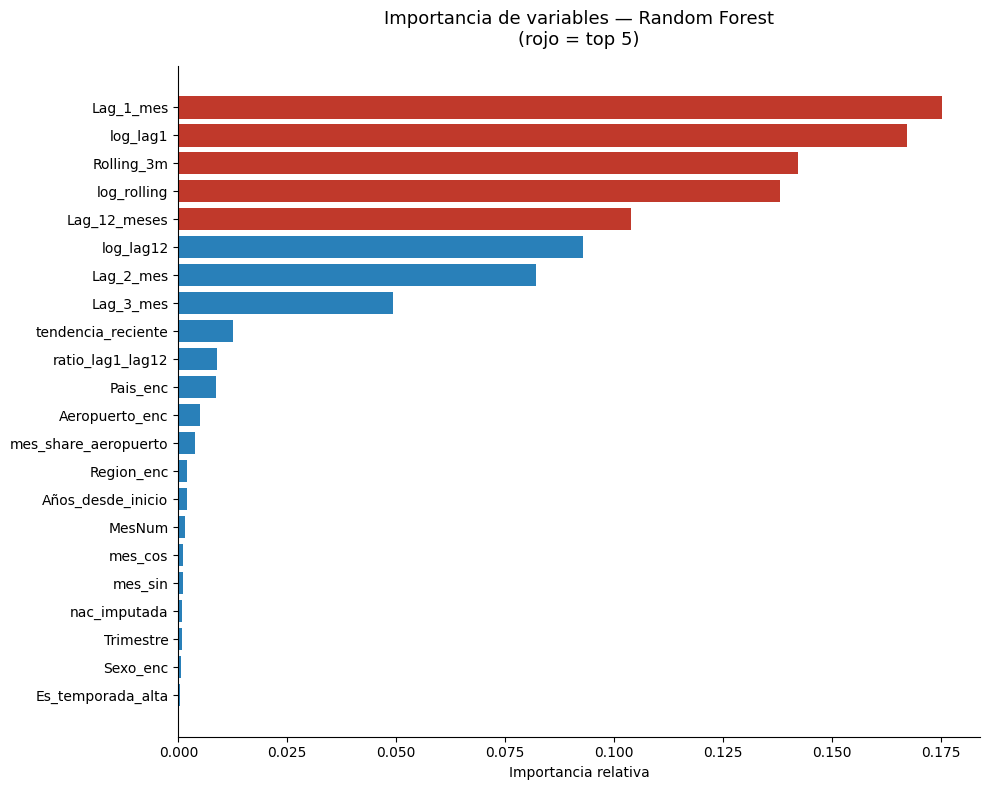

Ranking completo:
  Lag_1_mes               17.5%  ###########################################
  log_lag1                16.7%  #########################################
  Rolling_3m              14.2%  ###################################
  log_rolling             13.8%  ##################################
  Lag_12_meses            10.4%  #########################
  log_lag12                9.3%  #######################
  Lag_2_mes                8.2%  ####################
  Lag_3_mes                4.9%  ############
  tendencia_reciente       1.3%  ###
  ratio_lag1_lag12         0.9%  ##
  Pais_enc                 0.9%  ##
  Aeropuerto_enc           0.5%  #
  mes_share_aeropuerto     0.4%  #
  Region_enc               0.2%  #
  Años_desde_inicio        0.2%  #
  MesNum                   0.1%  #
  mes_cos                  0.1%  #
  mes_sin                  0.1%  #
  nac_imputada             0.1%  #
  Trimestre                0.1%  #
  Sexo_enc                 0.1%  #
  Es_temporada_alt

In [6]:
importancias = pd.Series(
    rf.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colores = ['#c0392b' if i < 5 else '#2980b9' for i in range(len(importancias))]
ax.barh(importancias.index[::-1], importancias.values[::-1],
        color=colores[::-1], edgecolor='none')
ax.set_title('Importancia de variables — Random Forest\n(rojo = top 5)', fontsize=13, pad=15)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('rf_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

print("Ranking completo:")
for feat, imp in importancias.items():
    barra = '#' * max(1, int(imp * 250))
    print(f"  {feat:<22} {imp*100:5.1f}%  {barra}")

print(f"\nTop 5 acumulan: {importancias.head(5).sum()*100:.1f}% de la importancia total")

## 7. Diagnostico visual — Error por mes

El grafico de la derecha muestra el error porcentual mediano por mes
calculado solo sobre registros con 50 o mas turistas.
Los errores en registros pequenos (1-5 turistas) producen porcentajes
extremos que no tienen relevancia para decisiones de negocio.

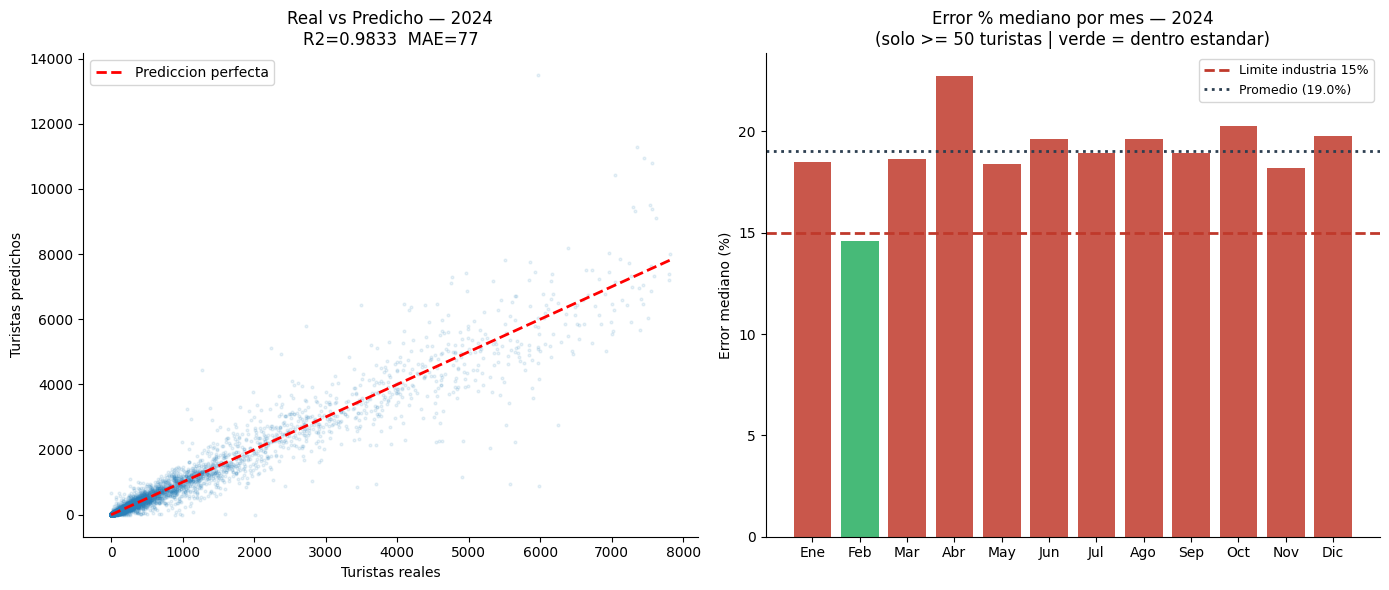

Meses con error > 15% en 2024: ['Ene', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafica 1: Real vs Predicho en 2024
y24 = val24[TARGET].values
p99 = np.percentile(y24, 99)
mask_99 = y24 <= p99
axes[0].scatter(y24[mask_99], pred24[mask_99],
                alpha=0.1, s=4, color='#2980b9', rasterized=True)
axes[0].plot([0,p99],[0,p99],'r--', lw=2, label='Prediccion perfecta')
axes[0].set_xlabel('Turistas reales')
axes[0].set_ylabel('Turistas predichos')
axes[0].set_title(f'Real vs Predicho — 2024\nR2={m24["r2"]}  MAE={m24["mae"]:,.0f}')
axes[0].legend()

# Grafica 2: error por mes en 2024 sobre registros de negocio
v24 = val24.copy()
v24['pred'] = pred24
v24['err_pct'] = abs(v24[TARGET] - v24['pred']) / v24[TARGET].clip(lower=1) * 100
err_mes = v24[v24[TARGET] >= UMBRAL_NEGOCIO].groupby('MesNum')['err_pct'].median()

colores_mes = ['#c0392b' if v > 15 else '#27ae60' for v in err_mes.values]
axes[1].bar(meses_lbl, err_mes.values, color=colores_mes, alpha=0.85, edgecolor='none')
axes[1].axhline(y=15, color='#c0392b', ls='--', lw=2, label='Limite industria 15%')
axes[1].axhline(y=err_mes.mean(), color='#2c3e50', ls=':',
                lw=2, label=f'Promedio ({err_mes.mean():.1f}%)')
axes[1].set_title(f'Error % mediano por mes — 2024\n(solo >= {UMBRAL_NEGOCIO} turistas | verde = dentro estandar)')
axes[1].set_ylabel('Error mediano (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('rf_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()

meses_sobre = [meses_lbl[i-1] for i,v in err_mes.items() if v > 15]
print(f"Meses con error > 15% en 2024: {meses_sobre}")

## 8. Demo — Cancun · EE.UU. · Mujeres

Segmento principal del proyecto. Mujeres residentes en Estados Unidos
que arriban al aeropuerto de Cancun. Concentra el mayor volumen
de turistas del dataset y es el caso de uso central para el pitch.

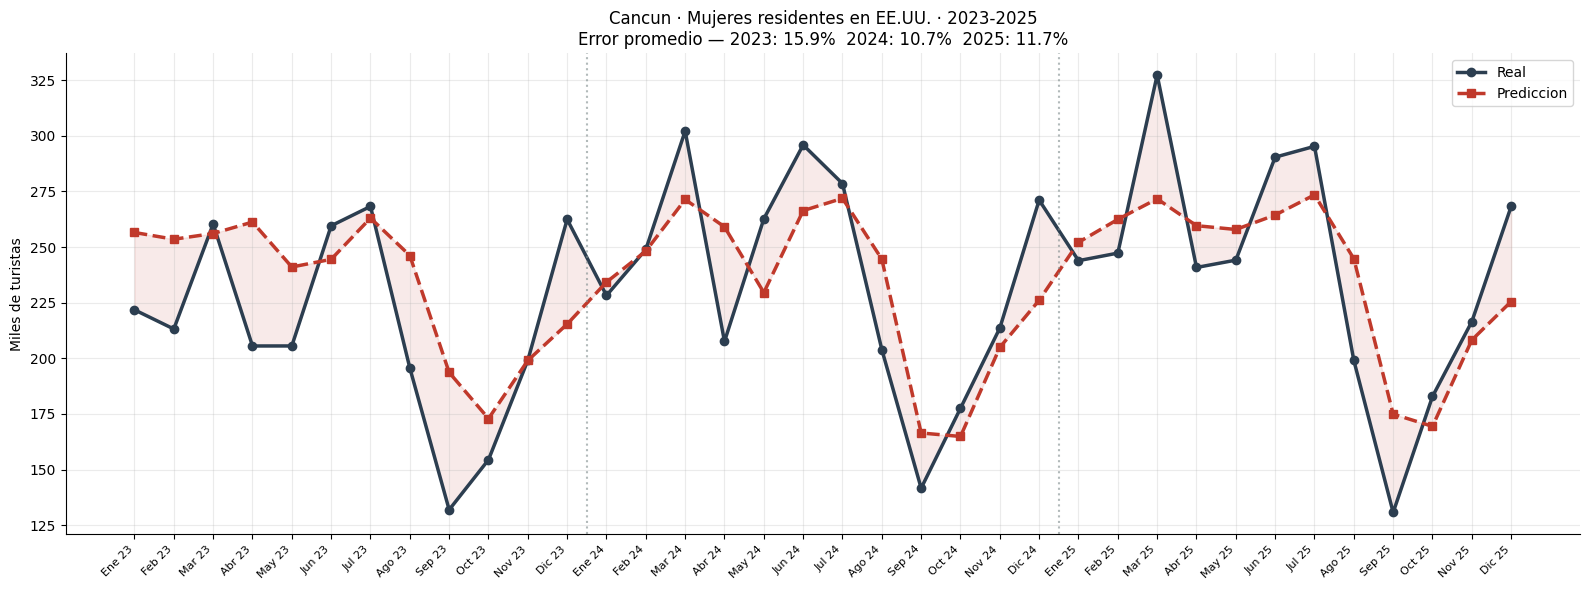

Error promedio por anio:
  2023: 15.9%
  2024: 10.7%
  2025: 11.7%

Detalle mes a mes:
   Mes  Valor_Residencia    Prediccion  Error_pct
Ene 23            221806 256556.032076       15.7
Feb 23            213190 253519.736814       18.9
Mar 23            260371 256095.786832        1.6
Abr 23            205558 261245.828084       27.1
May 23            205572 241045.627899       17.3
Jun 23            259565 244488.112604        5.8
Jul 23            268271 263031.514945        2.0
Ago 23            195684 246212.092688       25.8
Sep 23            131970 193666.317485       46.8
Oct 23            154433 172925.702864       12.0
Nov 23            199131 199053.247504        0.0
Dic 23            262450 215394.393246       17.9
Ene 24            228242 234258.789355        2.6
Feb 24            248937 248206.821553        0.3
Mar 24            302152 271375.316108       10.2
Abr 24            207580 259083.914841       24.8
May 24            262677 229551.274345       12.6
Jun 24       

In [8]:
# Concatenar todos los conjuntos de validacion y sus predicciones
val_todo = pd.concat([val23, val24, val25]).copy()
pred_todo = np.concatenate([pred23, pred24, pred25])
pred_series = pd.Series(pred_todo, index=val_todo.index)
val_todo['Prediccion'] = pred_series
val_todo['Error_pct']  = (abs(val_todo[TARGET] - val_todo['Prediccion']) /
                          val_todo[TARGET] * 100).round(1)
val_todo['Mes'] = (val_todo['MesNum'].map(dict(enumerate(meses_lbl,1))) +
                   ' ' + val_todo['Ano'].astype(str).str[-2:])

def graficar_segmento(aeropuerto, pais=None, sexo=None, titulo=None, nombre_archivo=None):
    """Grafica real vs prediccion para un segmento dado."""
    mask = val_todo['Aeropuerto'] == aeropuerto
    if pais:  mask &= val_todo['Pais'] == pais
    if sexo:  mask &= val_todo['Sexo'] == sexo
    seg = val_todo[mask].copy().sort_values(['Ano','MesNum'])
    if seg.empty:
        print(f"Sin datos: {aeropuerto} | {pais} | {sexo}")
        return
    err_por_anio = seg.groupby('Ano')['Error_pct'].mean()
    titulo_graf = titulo or f"{aeropuerto.title()}{' · '+pais.title() if pais else ''}"
    fig, ax = plt.subplots(figsize=(16, 6))
    x = range(len(seg))
    ax.plot(x, seg[TARGET]/1000,      'o-',  color='#2c3e50', lw=2.5, label='Real', ms=6)
    ax.plot(x, seg['Prediccion']/1000,'s--', color='#c0392b', lw=2.5, label='Prediccion', ms=6)
    ax.fill_between(x, seg[TARGET]/1000, seg['Prediccion']/1000, alpha=0.1, color='#c0392b')
    for corte_x in [12, 24]:
        ax.axvline(x=corte_x-0.5, color='#7f8c8d', ls=':', lw=1.5, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(seg['Mes'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Miles de turistas')
    err_str = '  '.join([f"{a}: {v:.1f}%" for a, v in err_por_anio.items()])
    ax.set_title(f"{titulo_graf} · 2023-2025\nError promedio — {err_str}")
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    fname = nombre_archivo or f"rf_{aeropuerto.split(',')[0].replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print("Error promedio por anio:")
    for a, v in err_por_anio.items():
        print(f"  {a}: {v:.1f}%")
    print("\nDetalle mes a mes:")
    print(seg[['Mes', TARGET, 'Prediccion', 'Error_pct']].to_string(index=False))

# Demo Cancun
graficar_segmento(
    aeropuerto='cancun, q. roo',
    pais='estados unidos',
    sexo='mujer',
    titulo='Cancun · Mujeres residentes en EE.UU.',
    nombre_archivo='rf_demo_cancun.png'
)

## 9. Demo — Merida, Yuc. · ¿De que region vienen mas turistas?

De que region del mundo llegan mas turistas a Merida, Yucatan?
Esta celda identifica automaticamente la region con mayor volumen
historico (hombres + mujeres sumados) y compara la serie real vs
prediccion del modelo. Permite evaluar si el modelo captura bien
el mercado emisor principal de un destino cultural como Merida,
cuyo perfil difiere significativamente del turismo de sol y playa.

Turistas reales por region hacia Merida, Yuc. (2023-2025, H+M):
           Región  Valor_Residencia    Prediccion
america del norte            222835 210312.014786
 islas del caribe             14808  14170.339992
           europa              8702   6980.507477
  america central              4008   3592.147272
             asia              2324   1830.033648
  america del sur              2278   1809.539644
          oceania              1065    789.208860
           africa               159    169.042951

Region con mayor flujo: AMERICA DEL NORTE


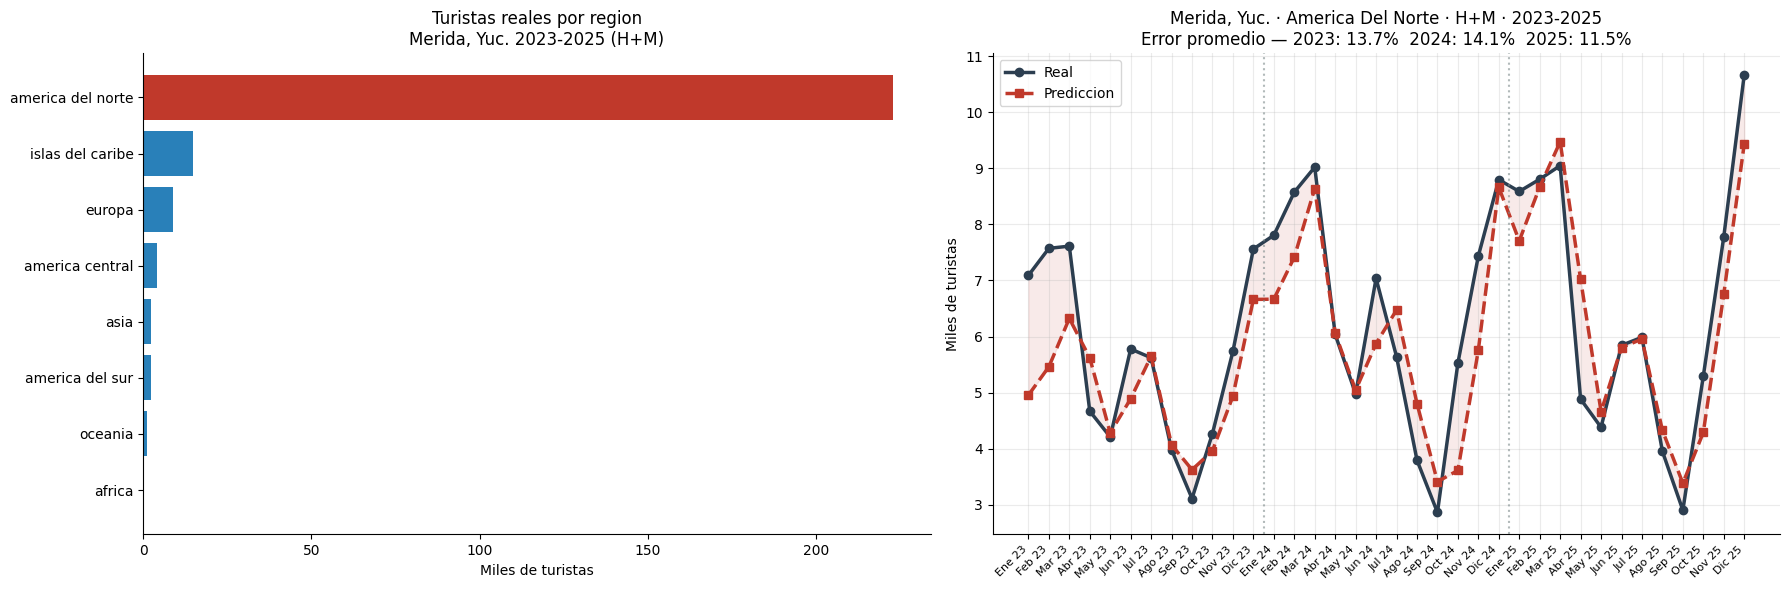


Detalle mes a mes:
   Mes  Real  Prediccion  Error_pct
Ene 23  7089 4955.175068       30.1
Feb 23  7572 5460.680550       27.9
Mar 23  7611 6321.683488       16.9
Abr 23  4670 5619.595824       20.3
May 23  4209 4280.853917        1.7
Jun 23  5778 4890.430779       15.4
Jul 23  5621 5647.984958        0.5
Ago 23  3980 4068.946938        2.2
Sep 23  3112 3624.808657       16.5
Oct 23  4271 3962.006891        7.2
Nov 23  5737 4938.224422       13.9
Dic 23  7560 6660.903261       11.9
Ene 24  7805 6666.043192       14.6
Feb 24  8573 7413.495487       13.5
Mar 24  9019 8637.125525        4.2
Abr 24  6037 6057.996226        0.3
May 24  4978 5043.601842        1.3
Jun 24  7036 5874.442688       16.5
Jul 24  5641 6473.131806       14.8
Ago 24  3796 4804.880193       26.6
Sep 24  2864 3411.741962       19.1
Oct 24  5526 3612.916096       34.6
Nov 24  7436 5758.172266       22.6
Dic 24  8796 8658.909139        1.6
Ene 25  8586 7705.169532       10.3
Feb 25  8804 8665.025596        1.6
Mar 25  

In [9]:
# Identificar la region con mayor flujo hacia Merida (hombres + mujeres sumados)
col_region = 'Región' if 'Región' in val_todo.columns else 'Region'
merida = val_todo[val_todo['Aeropuerto'] == 'merida, yuc.'].copy()

if merida.empty:
    print("Sin datos de validacion para Merida, Yuc.")
else:
    por_region = (merida.groupby(col_region)[[TARGET, 'Prediccion']]
                  .sum().reset_index()
                  .sort_values(TARGET, ascending=False))

    print("Turistas reales por region hacia Merida, Yuc. (2023-2025, H+M):")
    print(por_region.to_string(index=False))

    top_region = por_region.iloc[0][col_region]
    print(f"\nRegion con mayor flujo: {top_region.upper()}")

    seg = (merida[merida[col_region] == top_region]
           .groupby(['Ano', 'MesNum', 'Mes'])
           .agg(Real=(TARGET, 'sum'), Prediccion=('Prediccion', 'sum'))
           .reset_index()
           .sort_values(['Ano', 'MesNum']))
    seg['Error_pct'] = (abs(seg['Real'] - seg['Prediccion']) /
                        seg['Real'].clip(lower=1) * 100).round(1)
    err_por_anio = seg.groupby('Ano')['Error_pct'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Izquierda: ranking de regiones
    colores_barra = ['#c0392b' if i == 0 else '#2980b9' for i in range(len(por_region))]
    axes[0].barh(por_region[col_region][::-1],
                 por_region[TARGET][::-1] / 1000,
                 color=colores_barra[::-1], edgecolor='none')
    axes[0].set_title('Turistas reales por region\nMerida, Yuc. 2023-2025 (H+M)', fontsize=12)
    axes[0].set_xlabel('Miles de turistas')

    # Derecha: serie temporal de la top region
    x = range(len(seg))
    axes[1].plot(x, seg['Real'] / 1000,       'o-',  color='#2c3e50', lw=2.5, label='Real', ms=6)
    axes[1].plot(x, seg['Prediccion'] / 1000, 's--', color='#c0392b', lw=2.5, label='Prediccion', ms=6)
    axes[1].fill_between(x, seg['Real'] / 1000, seg['Prediccion'] / 1000, alpha=0.1, color='#c0392b')
    for corte_x in [12, 24]:
        axes[1].axvline(x=corte_x - 0.5, color='#7f8c8d', ls=':', lw=1.5, alpha=0.6)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(seg['Mes'], rotation=45, ha='right', fontsize=8)
    axes[1].set_ylabel('Miles de turistas')
    err_str = '  '.join([f"{a}: {v:.1f}%" for a, v in err_por_anio.items()])
    axes[1].set_title(f"Merida, Yuc. · {top_region.title()} · H+M · 2023-2025\nError promedio — {err_str}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig('rf_demo_merida_region.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nDetalle mes a mes:")
    print(seg[['Mes', 'Real', 'Prediccion', 'Error_pct']].to_string(index=False))

## 10. Demo — Region Asia · ¿A que destino mexicano van mas?

A que aeropuerto de Mexico llegan mas turistas provenientes de Asia?
Esta celda identifica el destino con mayor flujo asiatico acumulado
(todos los paises de la region, ambos sexos) y muestra la serie real
vs prediccion. Demuestra la utilidad del modelo para identificar
oportunidades en mercados emisores emergentes de largo recorrido,
donde la deteccion temprana de tendencias tiene alto valor estrategico.

Turistas reales de Asia por destino en Mexico (2023-2025, todos paises+sexos):
                      Aeropuerto  Valor_Residencia    Prediccion
         ciudad de mexico (aicm)            541340 486447.269084
                  cancun, q. roo            323505 324534.149805
               guadalajara, jal.             62344  51052.686495
                 monterrey, n.l.             61879  54944.686788
                   tijuana, b.c.             33711  23590.234729
           puerto vallarta, jal.             20713  19924.842424
                 queretaro, qro.             14484  11485.103212
                     silao, gto.             14358  12215.595123
felipe angeles (aifa), edo. mex.              9763   7120.889226
               los cabos, b.c.s.              9121   7450.057589

Destino con mayor flujo desde Asia: CIUDAD DE MEXICO (AICM)


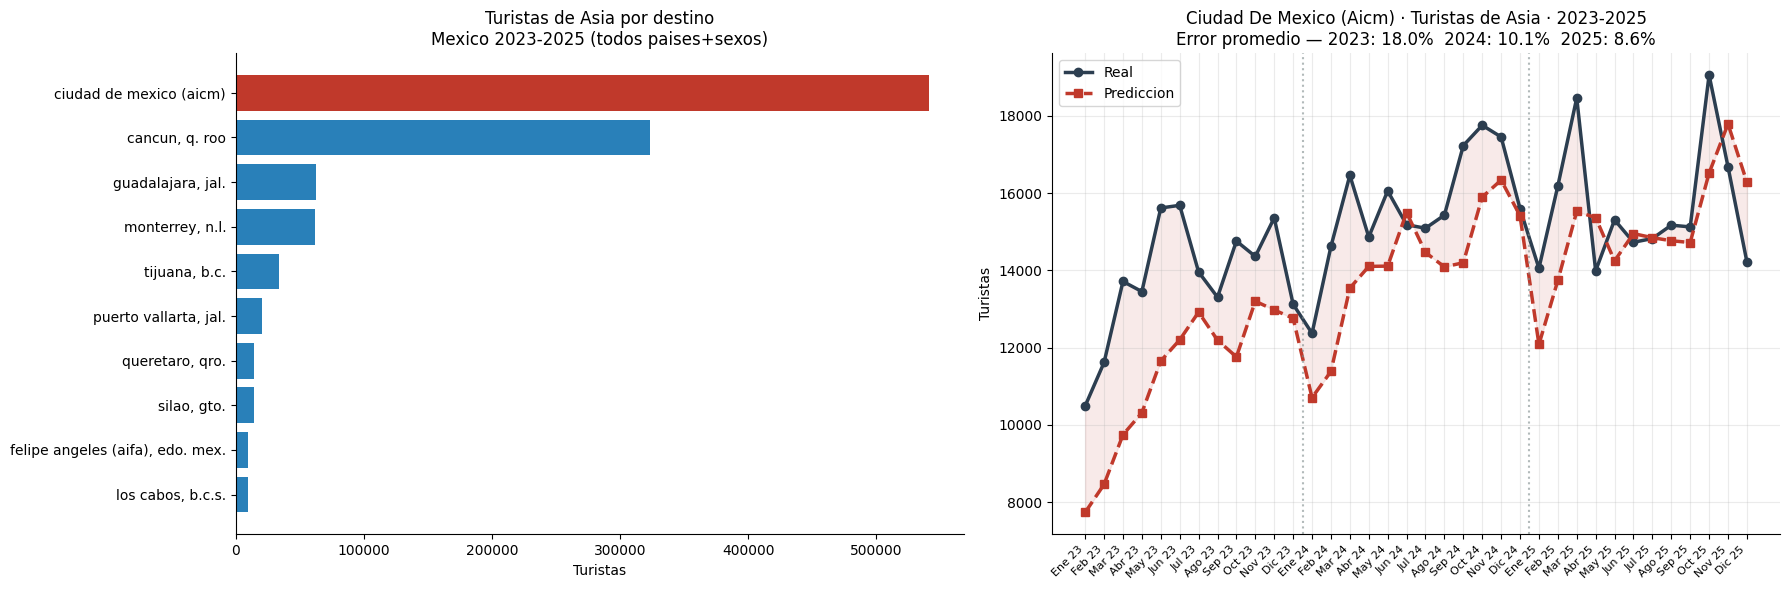


Detalle mes a mes:
   Mes  Real   Prediccion  Error_pct
Ene 23 10487  7729.817876       26.3
Feb 23 11613  8456.512318       27.2
Mar 23 13712  9741.353303       29.0
Abr 23 13450 10310.550069       23.3
May 23 15615 11652.266226       25.4
Jun 23 15684 12198.259998       22.2
Jul 23 13959 12917.776835        7.5
Ago 23 13304 12190.730051        8.4
Sep 23 14758 11757.698160       20.3
Oct 23 14360 13199.473283        8.1
Nov 23 15360 12973.791396       15.5
Dic 23 13121 12757.758443        2.8
Ene 24 12369 10702.154809       13.5
Feb 24 14619 11381.760465       22.1
Mar 24 16461 13538.986660       17.8
Abr 24 14863 14102.279680        5.1
May 24 16058 14109.092747       12.1
Jun 24 15181 15497.616310        2.1
Jul 24 15091 14463.892511        4.2
Ago 24 15429 14088.925909        8.7
Sep 24 17231 14196.836783       17.6
Oct 24 17757 15896.711716       10.5
Nov 24 17455 16337.668212        6.4
Dic 24 15599 15414.333045        1.2
Ene 25 14054 12081.195294       14.0
Feb 25 16185 13737

In [10]:
# Identificar el aeropuerto mexicano con mayor flujo desde Asia
col_region = 'Región' if 'Región' in val_todo.columns else 'Region'
asia = val_todo[val_todo[col_region].str.lower() == 'asia'].copy()

if asia.empty:
    print("Sin datos de validacion para la region Asia.")
else:
    por_aero = (asia.groupby('Aeropuerto')[[TARGET, 'Prediccion']]
                .sum().reset_index()
                .sort_values(TARGET, ascending=False))

    print("Turistas reales de Asia por destino en Mexico (2023-2025, todos paises+sexos):")
    print(por_aero.head(10).to_string(index=False))

    top_aero = por_aero.iloc[0]['Aeropuerto']
    print(f"\nDestino con mayor flujo desde Asia: {top_aero.upper()}")

    seg = (asia[asia['Aeropuerto'] == top_aero]
           .groupby(['Ano', 'MesNum', 'Mes'])
           .agg(Real=(TARGET, 'sum'), Prediccion=('Prediccion', 'sum'))
           .reset_index()
           .sort_values(['Ano', 'MesNum']))
    seg['Error_pct'] = (abs(seg['Real'] - seg['Prediccion']) /
                        seg['Real'].clip(lower=1) * 100).round(1)
    err_por_anio = seg.groupby('Ano')['Error_pct'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Izquierda: top destinos desde Asia
    top10 = por_aero.head(10)
    colores_barra = ['#c0392b' if i == 0 else '#2980b9' for i in range(len(top10))]
    axes[0].barh(top10['Aeropuerto'][::-1],
                 top10[TARGET][::-1],
                 color=colores_barra[::-1], edgecolor='none')
    axes[0].set_title('Turistas de Asia por destino\nMexico 2023-2025 (todos paises+sexos)', fontsize=12)
    axes[0].set_xlabel('Turistas')

    # Derecha: serie temporal del top aeropuerto
    x = range(len(seg))
    axes[1].plot(x, seg['Real'],       'o-',  color='#2c3e50', lw=2.5, label='Real', ms=6)
    axes[1].plot(x, seg['Prediccion'], 's--', color='#c0392b', lw=2.5, label='Prediccion', ms=6)
    axes[1].fill_between(x, seg['Real'], seg['Prediccion'], alpha=0.1, color='#c0392b')
    for corte_x in [12, 24]:
        axes[1].axvline(x=corte_x - 0.5, color='#7f8c8d', ls=':', lw=1.5, alpha=0.6)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(seg['Mes'], rotation=45, ha='right', fontsize=8)
    axes[1].set_ylabel('Turistas')
    err_str = '  '.join([f"{a}: {v:.1f}%" for a, v in err_por_anio.items()])
    axes[1].set_title(f"{top_aero.title()} · Turistas de Asia · 2023-2025\nError promedio — {err_str}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig('rf_demo_asia_destino.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nDetalle mes a mes:")
    print(seg[['Mes', 'Real', 'Prediccion', 'Error_pct']].to_string(index=False))

## 11. Tabla comparativa por anio de validacion

In [11]:
tabla = pd.DataFrame([
    {'Anio de validacion': '2023 (1 anio)', 'R2': m23['r2'], 'MAE': m23['mae'],
     'MAPE global (%)': m23['mape_g'], 'MAPE negocio (%)': m23['mape_n']},
    {'Anio de validacion': '2024 (2 anios)', 'R2': m24['r2'], 'MAE': m24['mae'],
     'MAPE global (%)': m24['mape_g'], 'MAPE negocio (%)': m24['mape_n']},
    {'Anio de validacion': '2025 (3 anios)', 'R2': m25['r2'], 'MAE': m25['mae'],
     'MAPE global (%)': m25['mape_g'], 'MAPE negocio (%)': m25['mape_n']},
])

print("=" * 72)
print("TABLA DE RESULTADOS — Random Forest")
print(f"Entrenado con: 2012-2022 ({len(train):,} observaciones)")
print(f"Estandar industrial: MAPE negocio < 15%")
print("=" * 72)
print(tabla.to_string(index=False))
print("=" * 72)

# Resumen para el pitch
print(f"\nResumen para la presentacion:")
print(f'"El modelo predice el flujo de turistas con un error mediano de {m24["mape_n"]}%')
print(f'en datos de 2024, 2 anios despues del cierre del entrenamiento.')
print(f'Entrenado sobre 13 anios de historia de 66 aeropuertos y 243 paises de origen."')

tabla.to_csv('resultados_rf.csv', index=False)

TABLA DE RESULTADOS — Random Forest
Entrenado con: 2012-2022 (267,799 observaciones)
Estandar industrial: MAPE negocio < 15%
Anio de validacion     R2  MAE  MAPE global (%)  MAPE negocio (%)
     2023 (1 anio) 0.9686 93.8             37.6              19.0
    2024 (2 anios) 0.9833 77.3             37.8              19.0
    2025 (3 anios) 0.9824 78.1             37.2              17.6

Resumen para la presentacion:
"El modelo predice el flujo de turistas con un error mediano de 19.0%
en datos de 2024, 2 anios despues del cierre del entrenamiento.
Entrenado sobre 13 anios de historia de 66 aeropuertos y 243 paises de origen."


## 12. Guardar modelo y archivos

In [12]:
# Modelo entrenado
with open('modelo_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Predicciones de los tres anios de validacion
pred_out = val_todo[['Ano','MesNum','Aeropuerto','Pais','Sexo',TARGET,'Prediccion','Error_pct']].copy()
pred_out.to_csv('predicciones_rf.csv', index=False)

# Metricas en JSON para comparar con otros modelos
metricas_json = {
    'Random Forest': {
        'r2_2023': m23['r2'], 'r2_2024': m24['r2'], 'r2_2025': m25['r2'],
        'mape_neg_2023': m23['mape_n'],
        'mape_neg_2024': m24['mape_n'],
        'mape_neg_2025': m25['mape_n'],
        'mae_2024': m24['mae'],
        'rmse_2024': m24['rmse'],
        'tiempo_s': TIEMPO,
        'n_estimators': 2000,
        'features': FEATURES
    }
}
with open('metricas_rf.json', 'w') as f:
    json.dump(metricas_json, f, indent=2)

archivos = ['modelo_rf.pkl', 'predicciones_rf.csv', 'resultados_rf.csv', 'metricas_rf.json']
print("=" * 55)
print("ARCHIVOS GENERADOS")
print("=" * 55)
for a in archivos:
    if os.path.exists(a):
        kb = os.path.getsize(a) / 1024
        unidad = 'MB' if kb > 1024 else 'KB'
        val_kb = kb/1024 if kb > 1024 else kb
        print(f"  {a:<38} {val_kb:>7.1f} {unidad}")

print(f"\n{'='*55}")
print("RESUMEN FINAL")
print(f"{'='*55}")
print(f"  Modelo          : Random Forest")
print(f"  Arboles         : {rf.n_estimators}")
print(f"  Features        : {len(FEATURES)}")
print(f"  Entrenamiento   : 2012-2022 ({len(train):,} filas)")
print(f"  R2  (2024)      : {m24['r2']}")
print(f"  MAE (2024)      : {m24['mae']:,.1f} turistas")
print(f"  MAPE neg. 2023  : {m23['mape_n']}%")
print(f"  MAPE neg. 2024  : {m24['mape_n']}%")
print(f"  MAPE neg. 2025  : {m25['mape_n']}%")
print(f"  Tiempo          : {TIEMPO}s")

ARCHIVOS GENERADOS
  modelo_rf.pkl                           7690.1 MB
  predicciones_rf.csv                        7.1 MB
  resultados_rf.csv                          0.2 KB
  metricas_rf.json                           0.8 KB

RESUMEN FINAL
  Modelo          : Random Forest
  Arboles         : 2000
  Features        : 22
  Entrenamiento   : 2012-2022 (267,799 filas)
  R2  (2024)      : 0.9833
  MAE (2024)      : 77.3 turistas
  MAPE neg. 2023  : 19.0%
  MAPE neg. 2024  : 19.0%
  MAPE neg. 2025  : 17.6%
  Tiempo          : 49.0s
